### Handling class imbalance for the 5 class classification

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils import class_weight
from scipy import stats

In [ ]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure your time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Create Buckets
bins = [-float('inf'), -1.5, -0.5, 0.5, 1.5, float('inf')]
labels = ['Severely Dry', 'Moderately Dry', 'Normal', 'Moderately Wet', 'Severely Wet']
labels = [0, 1, 2, 3, 4]
df['category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)
df["target_next_month"] = df["category"].shift(-14)
df = df.dropna()

In [13]:
print(df['category'].value_counts())

category
2    4671
1    4117
3    2633
4    1090
0     504
Name: count, dtype: int64


In [14]:
print(df['category'].value_counts(normalize=True) * 100)

category
2    35.889358
1    31.632731
3    20.230503
4     8.374952
0     3.872455
Name: proportion, dtype: float64


#### Data exploration: Pearson correlation coefficient

In [ ]:
pcc, p_value = stats.pearsonr(df['category'], df['target_next_month'])

print(f"Pearson Correlation: {pcc:.4f}")
print(f"P-value: {p_value:.4f}")

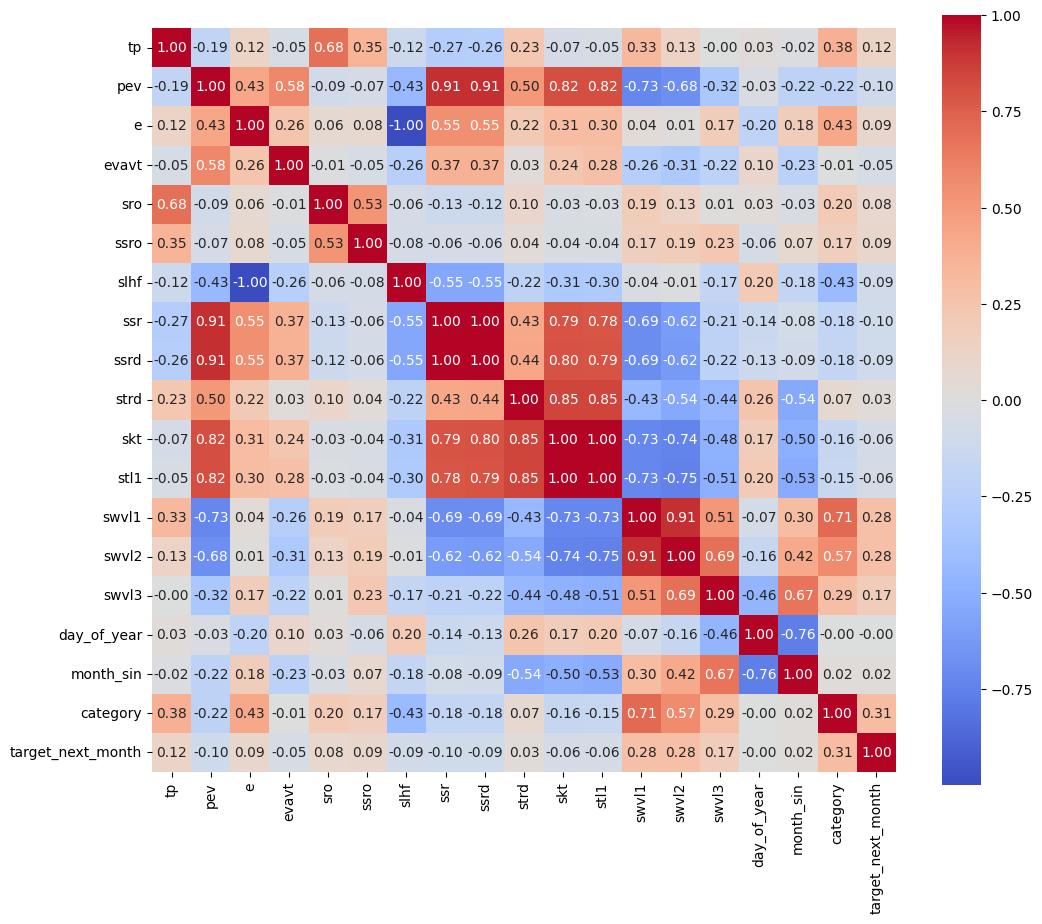

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10)) # Make the plot large enough to see
sns.heatmap(X.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.show()

#### Handling class imbalance

Picking different steps (xgboost)

In [ ]:
top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
X = df[features]
y = df['target_next_month']

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

# Define our "Steps" for each class
# Class 0: Sev Dry, Class 1: Mod Dry, Class 2: Normal, Class 3: Mod Wet, Class 4: Sev Wet
steps = {
    0: 1,  # Keep every single day for Severely Dry
    4: 1,  # Keep every single day for Severely Wet
    1: 3,  # Keep every 3rd day for Moderately Dry
    3: 3,  # Keep every 3rd day for Moderately Wet
    2: 10  # Keep only every 10th day for Normal
}

# Create a mask to filter the training data
keep_indices = []
for label, step in steps.items():
    # Get all indices where this class occurs
    class_indices = train_df[train_df['target_next_month'] == label].index
    # Take every Nth index based on the 'step'
    sampled_indices = class_indices[::step]
    keep_indices.extend(sampled_indices)

# Rebuild the balanced training set
# We sort the indices to keep the time-order (though XGBoost doesn't strictly require it)
train_df_balanced = train_df.loc[sorted(keep_indices)]

X_train = train_df_balanced[features]
y_train = train_df_balanced['target_next_month']

# Now check the new distribution
print("New Training Class Distribution:")
print(y_train.value_counts(normalize=True))

model = XGBClassifier(
    n_estimators=50,           # Reduce from 100 to prevent long-term memorization
    max_depth=3,               # Keep trees shallow (3-4 max)
    learning_rate=0.05,        # Slow down the learning
    min_child_weight=10,       # Prevents creating nodes for just 1 or 2 specific days
    subsample=0.8,             # Train on 80% of rows each time (adds randomness)
    colsample_bytree=0.8,      # Train on 80% of features each time
    gamma=1.0,                 # Minimum loss reduction to make a split
    objective='multi:softmax',
    num_class=5
)

model.fit(X_train, y_train)

New Training Class Distribution:
target_next_month
1.0    0.322655
4.0    0.251371
3.0    0.194517
0.0    0.123521
2.0    0.107937
Name: proportion, dtype: float64


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy Obtained: {accuracy:.2%}")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"--- Model Results ---")
print(f"Test Accuracy Obtained: {accuracy:.2%}")
print(f"F1 Obtained: {f1:.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Sev Dry', 'Mod Dry', 'Normal', 'Mod Wet', 'Sev Wet']))

Training Accuracy Obtained: 50.19%
--- Model Results ---
Test Accuracy Obtained: 30.73%
F1 Obtained: 22.91%

Classification Report:

              precision    recall  f1-score   support

     Sev Dry       0.17      0.41      0.24        76
     Mod Dry       0.37      0.80      0.51       762
      Normal       0.33      0.00      0.00       938
     Mod Wet       0.32      0.11      0.16       608
     Sev Wet       0.16      0.43      0.24       219

    accuracy                           0.31      2603
   macro avg       0.27      0.35      0.23      2603
weighted avg       0.32      0.31      0.21      2603



3 classes

In [ ]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure your time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# 5. Create Buckets
bins = [-float('inf'), -0.5, 0.5, float('inf')]
labels = ['Severely Dry','Moderately Dry', 'Normal', 'Moderately Wet', 'Severely Wet']
labels = [0, 1, 2]
df['target_category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)

df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df['tp_90d_sum'] = df['tp'].rolling(window=90, center=False).sum()
# df['pev_30d_sum'] = df['pev'].rolling(window=30, center=False).sum()
df["target_next_month"] = df["target_category"].shift(-30)
df = df.dropna()
features = ['ssrd', 'pev', 'day_of_year', 'swvl2', 'tp_30d_sum']
features = ['tp', 'pev', 'e', 'evabs', 'evavt', 'ro', 'sro', 'ssro', 'smlt', 'slhf',
       'ssr', 'ssrd', 'str', 'strd', 't2m', 'd2m', 'skt', 'stl1', 'stl2', 'sd',
       'swvl1', 'swvl2', 'swvl3', 'swvl4', 'day_of_year', 'month_sin', 'month_cos', 'tp_30d_sum', 'tp_90d_sum', 'target_category']
X = df[features]
y = df['target_next_month']

# TRAIN-TEST SPLIT (80/20)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Calculate weights based on how rare each category is
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y_train), 
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))
sample_weights = [class_weights_dict[label] for label in y_train]

model = XGBClassifier(
    n_estimators=50,           # Reduce from 100 to prevent long-term memorization
    max_depth=3,               # VERY IMPORTANT: Keep trees shallow (3-4 max)
    learning_rate=0.05,        # Slow down the learning
    min_child_weight=10,       # Prevents creating nodes for just 1 or 2 specific days
    subsample=0.8,             # Train on 80% of rows each time (adds randomness)
    colsample_bytree=0.8,      # Train on 80% of features each time
    gamma=1.0,                 # Minimum loss reduction to make a split
    objective='multi:softmax',
    num_class=5
)
# xgboost, change max step from 2 to 20, draw a diagram

model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy Obtained: {accuracy:.2%}")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred, average='weighted')


print(f"--- Model Results ---")
print(f"Test Accuracy Obtained: {accuracy:.2%}")
print(f"FINAL TEST F1 SCORE: {final_f1:.4f} (Weighted)")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Dry', 'Normal', 'Wet']))

Training Accuracy Obtained: 58.31%
--- Model Results ---
Test Accuracy Obtained: 42.23%
FINAL TEST F1 SCORE: 0.4140 (Weighted)

Classification Report:

              precision    recall  f1-score   support

         Dry       0.41      0.57      0.48       385
      Normal       0.48      0.28      0.36       401
         Wet       0.40      0.42      0.41       353

    accuracy                           0.42      1139
   macro avg       0.43      0.42      0.41      1139
weighted avg       0.43      0.42      0.41      1139



In [ ]:
print(df['target_category'].value_counts())

target_category
1    2062
0    1998
2    1634
Name: count, dtype: int64
